# Spotify Data Analysis

In [313]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Reading Data

In [314]:
# artist data
df_artist = pd.read_csv(r'C:\Users\Administrator\Desktop\Data Science\Data analysis\data sets\spotify data set\artists.csv')

In [315]:
df_artist.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


In [316]:
df_artist.shape

(1104349, 5)

### Cleaning Data

In [317]:
df_artist.isnull().sum()

id             0
followers     13
genres         0
name           3
popularity     0
dtype: int64

In [318]:
df_artist.dropna(inplace=True)

In [319]:
df.duplicated().sum()

0

### Descover Data

In [320]:
df_artist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1104333 entries, 0 to 1104348
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id          1104333 non-null  object 
 1   followers   1104333 non-null  float64
 2   genres      1104333 non-null  object 
 3   name        1104333 non-null  object 
 4   popularity  1104333 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 50.6+ MB


In [321]:
df_artist.describe()

,followers,popularity
count,1.104333e+06,1.104333e+06
mean,1.074307e+04,9.083895e+00
std,2.609557e+05,1.376313e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+01,0.000000e+00
50%,5.900000e+01,2.000000e+00
75%,4.510000e+02,1.400000e+01
max,7.890023e+07,1.000000e+02


##### Ten Most Popular Artists

In [322]:
df_artist[['name','popularity']].sort_values(by='popularity',ascending=False,ignore_index=True).head(10)

,name,popularity
0,Justin Bieber,100
1,Bad Bunny,98
2,Drake,98
3,Taylor Swift,98
4,The Weeknd,96
5,BTS,96
6,Juice WRLD,96
7,Myke Towers,95
8,Ariana Grande,95
9,J Balvin,95


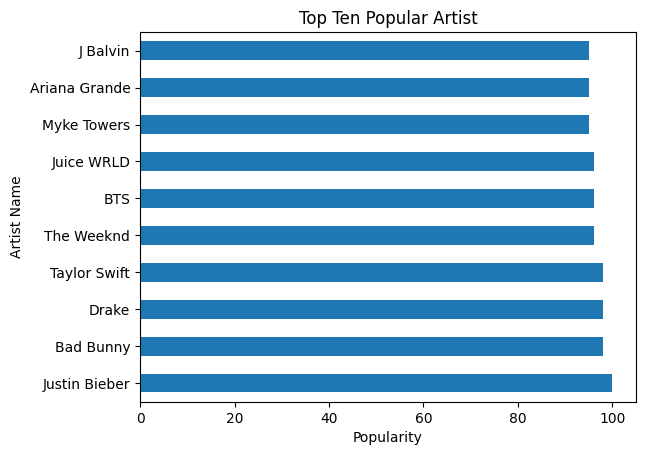

In [323]:
df_artist[['name','popularity']].sort_values(
    by='popularity',ascending=False,ignore_index=True
    ).head(10).plot(kind='barh',y='popularity',x='name',legend=False)
plt.xlabel('Popularity')
plt.ylabel('Artist Name')
plt.title('Top Ten Popular Artist')
plt.show()

##### list Popular Artists

In [324]:
df_artist[['name','popularity']].sort_values(by='popularity',ignore_index=True).head(10)

,name,popularity
0,Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,Bobby Vale,0
2,Villa & Vince,0
3,Sons Of Aliens,0
4,The Cyber Prince,0
5,The Desultory Ciphers,0
6,It Depends,0
7,Microecho,0
8,Anthrazit,0
9,Das,0


##### Ten Most Followed Artists

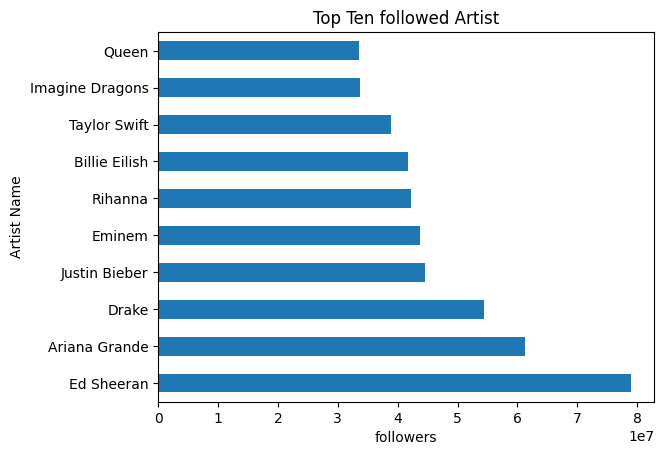

In [325]:
df_artist[['name','followers']].sort_values(
    by='followers',ascending=False,ignore_index=True
    ).head(10).plot(kind='barh',y='followers',x='name',legend=False)
plt.xlabel('followers')
plt.ylabel('Artist Name')
plt.title('Top Ten followed Artist')
plt.show()

In [326]:
df.groupby('name')['followers'].sum().sort_values(ascending=False)

name
Ed Sheeran       78900234.0
Ariana Grande    61301006.0
Drake            54430445.0
Justin Bieber    44606973.0
Eminem           43747833.0
                    ...    
Dybai                   0.0
John Kicau              0.0
QkaPishka               0.0
Dyb Hermes              0.0
Les Chambres            0.0
Name: followers, Length: 1078659, dtype: float64

### Track Data 

In [374]:
df_tracks = pd.read_csv(r'C:\Users\Administrator\Desktop\Data Science\Data analysis\data sets\spotify data set\tracks.csv')

In [375]:
df_tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [376]:
df_tracks.isnull().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

In [377]:
df.duplicated().sum()

0

In [378]:
df_tracks = df_tracks.dropna()

### Feature Engineering

In [379]:
df_tracks['year'] = df_tracks['release_date'].str.split('-',expand=True)[0]
df_tracks['month'] = df_tracks['release_date'].str.split('-',expand=True)[1]

In [380]:
df_tracks['duration_m'] = round(df_tracks['duration_ms']/60000,2)

### Trend Over Time

#### 1. No Of Tracks Per Year

In [381]:
df_tracks['year'].value_counts().reset_index().head()

,year,count
0,2020,13937
1,1999,12484
2,1998,12483
3,1997,12349
4,1996,12058


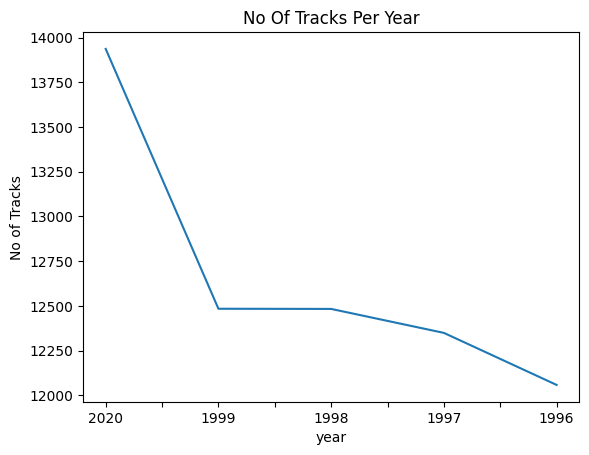

In [382]:
df_tracks['year'].value_counts().reset_index().head().plot(kind='line',x='year',y='count',legend=False)
plt.xlabel('year')
plt.ylabel('No of Tracks')
plt.title('No Of Tracks Per Year')
plt.show()

#### 2. No Of Tracks Per Month

In [384]:
df_tracks['month'].value_counts().reset_index().sort_values(by='month',ignore_index=True)

,month,count
0,01,135279
1,02,21908
2,03,29066
3,04,26632
4,05,25980
5,06,27668
6,07,25070
7,08,22749
8,09,28946
9,10,31559


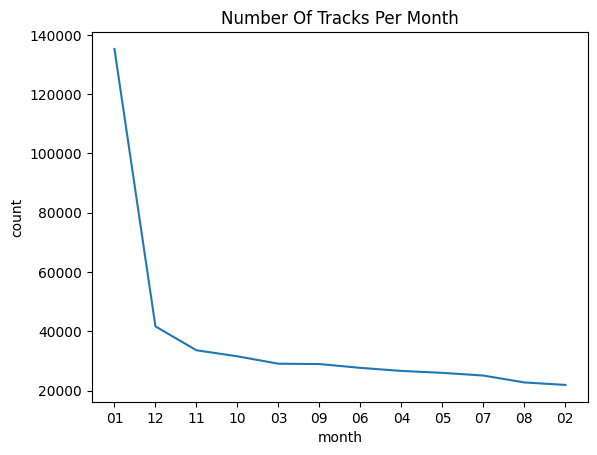

In [395]:
tracks_per_month = df_tracks['month'].value_counts()
sns.lineplot(data=tracks_per_month)
plt.title('Number Of Tracks Per Month')
plt.show()

#### 3. Average Popularity Per Year

In [418]:
df_tracks.groupby('year')['popularity'].mean().sort_values(ascending=False)

year
2019    44.920551
2020    44.686948
2017    42.236222
2018    42.139539
2016    39.280339
          ...    
1934     0.805732
1927     0.655000
1924     0.612954
1929     0.342806
1922     0.057971
Name: popularity, Length: 101, dtype: float64

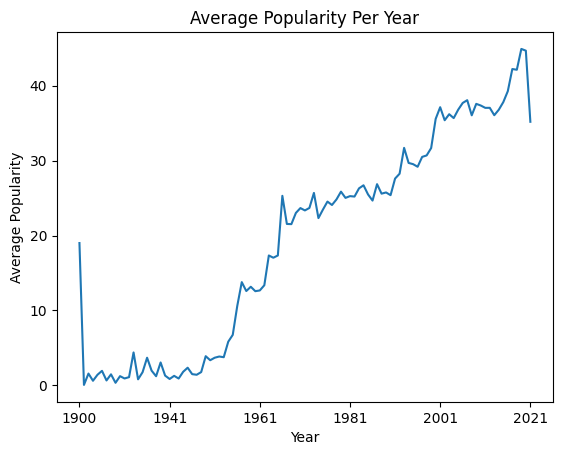

In [423]:
df_tracks.groupby('year')['popularity'].mean().plot()
plt.title('Average Popularity Per Year')
plt.xlabel("Year")
plt.ylabel("Average Popularity")
plt.show()

#### 3. Average danceability, energy, valence by year

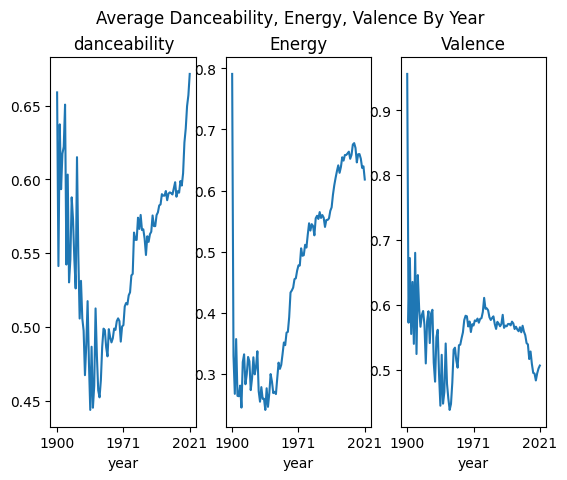

In [442]:
plt.subplot(1,3,1)
df_tracks.groupby('year')['danceability'].mean().plot()
plt.title('danceability')
plt.subplot(1,3,2)
df_tracks.groupby('year')['energy'].mean().plot()
plt.title('Energy')
plt.subplot(1,3,3)
df_tracks.groupby('year')['valence'].mean().plot()
plt.title('Valence')
plt.suptitle('Average Danceability, Energy, Valence By Year')
plt.show()

###  Track Popularity

In [396]:
df_tracks['popularity'].describe()

count    586601.000000
mean         27.573212
std          18.369417
min           0.000000
25%          13.000000
50%          27.000000
75%          41.000000
max         100.000000
Name: popularity, dtype: float64

In [397]:
df_tracks.sort_values(by='popularity', ascending=False).head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,year,month,duration_m
93802,4iJyoBOLtHqaGxP12qzhQI,Peaches (feat. Daniel Caesar & Giveon),100,198082,1,"['Justin Bieber', 'Daniel Caesar', 'Giveon']","['1uNFoZAHBGtllmzznpCI3s', '20wkVLutqVOYrc0kxF...",2021-03-19,0.677,0.696,...,0.1190,0.3210,0.000000,0.420,0.464,90.030,4,2021,03,3.30
93803,7lPN2DXiMsVn7XUKtOW1CS,drivers license,99,242014,1,['Olivia Rodrigo'],['1McMsnEElThX1knmY4oliG'],2021-01-08,0.585,0.436,...,0.0601,0.7210,0.000013,0.105,0.132,143.874,4,2021,01,4.03
93804,3Ofmpyhv5UAQ70mENzB277,Astronaut In The Ocean,98,132780,0,['Masked Wolf'],['1uU7g3DNSbsu0QjSEqZtEd'],2021-01-06,0.778,0.695,...,0.0913,0.1750,0.000000,0.150,0.472,149.996,4,2021,01,2.21
92811,6tDDoYIxWvMLTdKpjFkc1B,telepatía,97,160191,0,['Kali Uchis'],['1U1el3k54VvEUzo3ybLPlM'],2020-12-04,0.653,0.524,...,0.0502,0.1120,0.000000,0.203,0.553,83.970,4,2020,12,2.67
92810,5QO79kh1waicV47BqGRL3g,Save Your Tears,97,215627,1,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,0.680,0.826,...,0.0309,0.0212,0.000012,0.543,0.644,118.051,4,2020,03,3.59


### Tracks Duration Distribution

<Axes: >

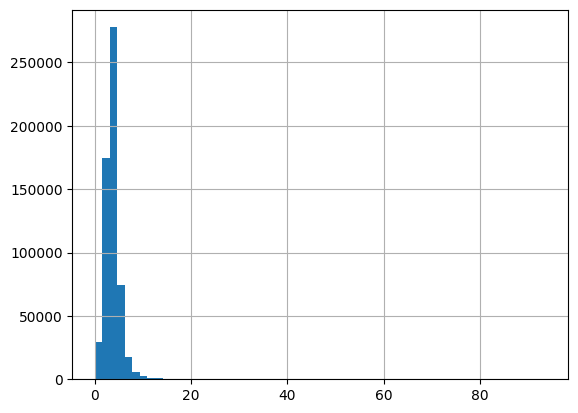

In [403]:
df_tracks['duration_m'].hist(bins=60)

### Audio Feature Exploration

#### 1. Danceability vs Energy (scatter plot)

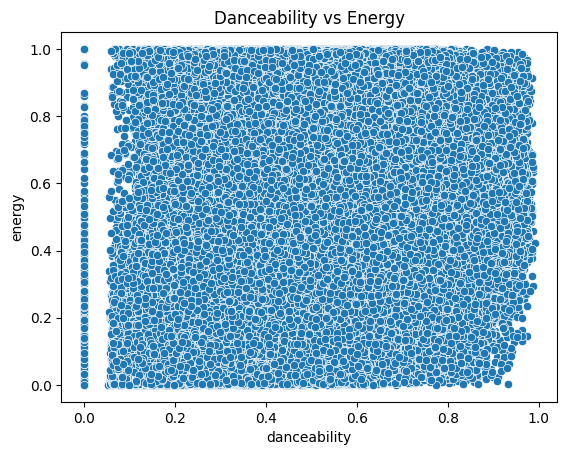

In [404]:
sns.scatterplot(data=df_tracks, x='danceability', y='energy')
plt.title('Danceability vs Energy')
plt.show()

#### 2. Valence vs Tempo (do upbeat songs go faster?)

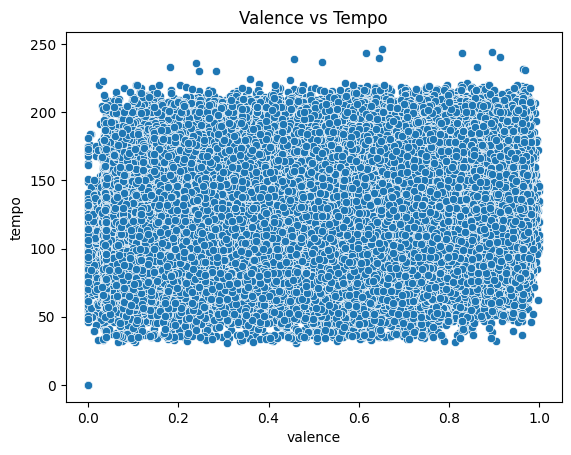

In [405]:
sns.scatterplot(data=df_tracks, x='valence', y='tempo')
plt.title('Valence vs Tempo')
plt.show()

#### 3. Instrumentalness vs Acousticness

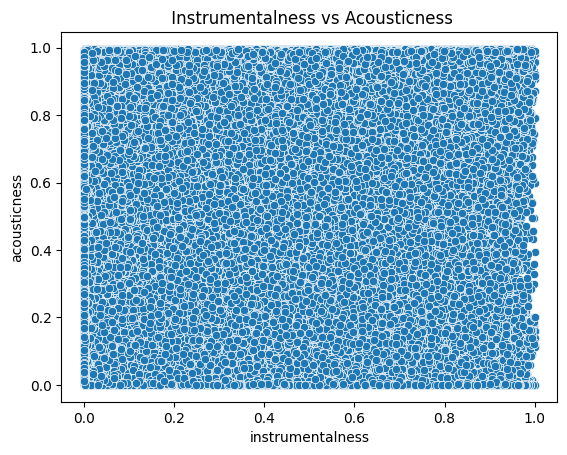

In [406]:
sns.scatterplot(data=df_tracks, x='instrumentalness', y='acousticness')
plt.title(' Instrumentalness vs Acousticness')
plt.show()

### Explicit vs Non-explicit Tracks

Compare popularity of explicit vs clean tracks

In [413]:
df_tracks.groupby('explicit')['popularity'].mean().reset_index()

,explicit,popularity
0,0,26.737833
1,1,45.684426


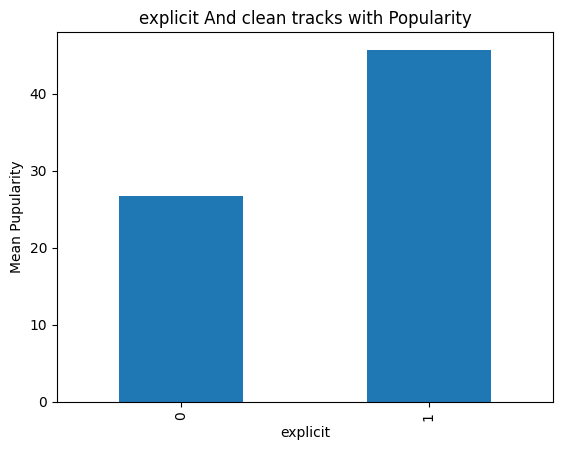

In [411]:
df_tracks.groupby('explicit')['popularity'].mean().plot(kind='bar')
plt.ylabel('Mean Pupularity')
plt.title('explicit And clean tracks with Popularity')
plt.show()

In [ ]:
Interesting Questions You Can Answer:
Do happier songs (high valence) tend to be more popular?

How has danceability or energy changed over the years?

Which artist consistently puts out high-popularity tracks?

Are most popular songs in major or minor key?

Do happier songs (high valence) tend to be more popular?

In [512]:
tracks_valence_popularity = df_tracks.groupby('valence')['popularity'].mean().sort_values(ascending=False).reset_index()
tracks_valence_popularity.columns = ['valence','average popularity']
tracks_valence_popularity.sort_values(by='average popularity', ascending=False)

,valence,average popularity
0,0.002280,75.0
1,0.005320,73.0
2,0.009870,67.0
3,0.005580,66.0
4,0.005480,65.0
...,...,...
1800,0.022100,0.0
1801,0.000064,0.0
1802,0.021000,0.0
1803,0.008240,0.0


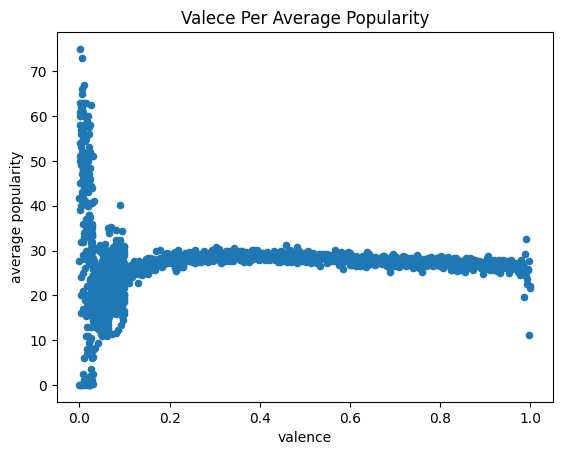

In [516]:
tracks_valence_popularity.sort_values(by='average popularity', ascending=False).plot(kind='scatter',x='valence',y='average popularity')
plt.title('Valece Per Average Popularity')
plt.show()

Are most popular songs in major or minor key?

In [497]:
tracks_mode = df_tracks.groupby('mode')['popularity'].mean().reset_index()
tracks_mode.columns = ['mode','average popularity']
tracks_mode

,mode,average popularity
0,0,28.432181
1,1,27.128337


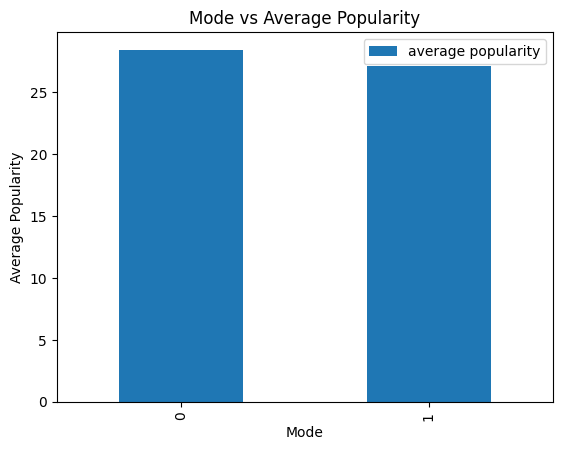

In [499]:
tracks_mode.plot(kind='bar',x='mode',y='average popularity')
plt.xlabel('Mode')
plt.ylabel('Average Popularity')
plt.title('Mode vs Average Popularity')
plt.show()

Which artist consistently puts out high-popularity tracks?

In [503]:
artists_popularity = df_tracks.groupby('artists')['popularity'].mean().reset_index().head()
artists_popularity.columns = ['artists','average popularity']
artists_popularity.sort_values(by='average popularity', ascending=False, ignore_index=False)

,artists,average popularity
0,"[""'In The Heights' Original Broadway Company"",...",55.000000
1,"[""'Om' Alec Khaoli & Umoja""]",38.000000
4,"[""'Til Tuesday""]",35.875000
2,"[""'T Hof Van Commerce"", 'TLP']",29.000000
3,"[""'T Hof Van Commerce""]",25.166667


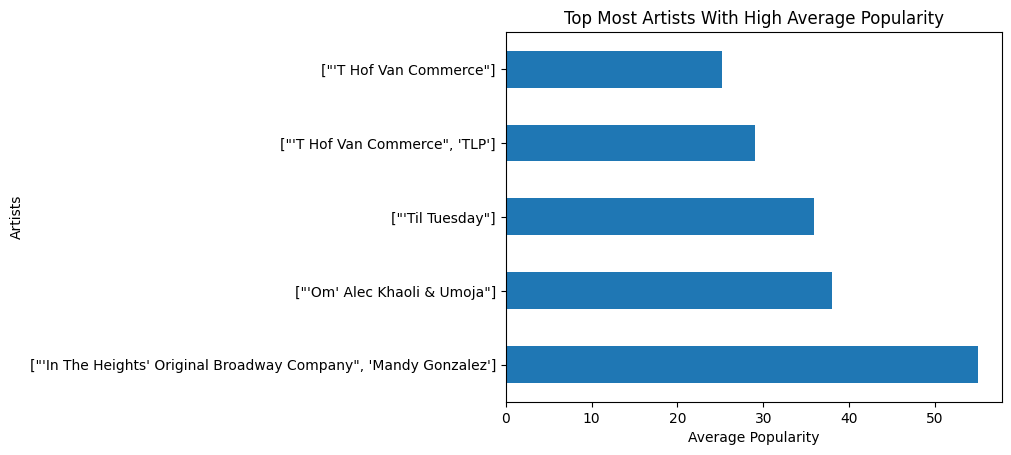

In [508]:
artists_popularity.sort_values(
    by='average popularity', ascending=False, ignore_index=False
    ).plot(kind='barh',y='average popularity',x='artists',legend=False)
plt.ylabel('Artists')
plt.xlabel('Average Popularity')
plt.title('Top Most Artists With High Average Popularity')
plt.show()